# Task 1 — Historical PM2.5 Data and Trend Attributes
**Feature Category 1 from literature review**

This notebook engineers historical PM2.5 features for **London Marylebone Road** covering 2016–2025.

Features produced:
- **Raw lag features** — PM2.5 values from previous 1, 7, 14 and 30 days
- **Rolling averages** — 3, 7, 14 and 30 day rolling means
- **Rolling statistics** — standard deviation, min, max
- **Rate of change** — day-on-day difference, 7-day difference, percentage change
- **Seasonal components** — trend and seasonality extracted via decomposition

**Files needed:**
- `AirQualityDataDaily2016_2020.csv` — upload to `/content/`
- `AirQualityDataDaily2021_2025.csv` — upload to `/content/`

---

## 0. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

print('All imports done!')

All imports done!


## 1. Load and Merge PM2.5 Data
Load both CSV files and combine into one continuous daily series for London Marylebone Road.

In [4]:
def load_defra_single_station(filepath):
    """
    Load a DEFRA daily CSV for a single station.
    Skips 11 metadata rows, returns clean date + pm25 dataframe.
    """
    raw = pd.read_csv(filepath, skiprows=11, header=None,
                      usecols=[0, 1], names=['date', 'pm25'])
    # Drop non-date rows (e.g. blank rows, End row at bottom)
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

# Load only the 2021-2025 file
df = load_defra_single_station('/content/PM2.5_AirQualityDataDaily_2021-2025.csv')

# Sort and drop duplicates
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)

# Add station name
df['station'] = 'London Marylebone Road'

print(f'Combined shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing PM2.5 values: {df["pm25"].isna().sum()}')
df.head(10)

Combined shape: (720, 3)
Date range: 2021-01-01 to 2025-12-12
Missing PM2.5 values: 33


,date,pm25,station
0,2021-01-01,17.167,London Marylebone Road
1,2021-01-02,13.724,London Marylebone Road
2,2021-01-03,26.917,London Marylebone Road
3,2021-01-04,17.167,London Marylebone Road
4,2021-01-05,10.000,London Marylebone Road
5,2021-01-06,12.385,London Marylebone Road
6,2021-01-07,7.720,London Marylebone Road
7,2021-01-08,4.333,London Marylebone Road
8,2021-01-09,6.417,London Marylebone Road
9,2021-01-10,6.083,London Marylebone Road


## 2. Basic Cleaning
Remove impossible values and fill the time index so it is fully continuous.

Negative values removed: 0
Missing values after reindex: 1120 (62.0%)
Total days in series: 1807


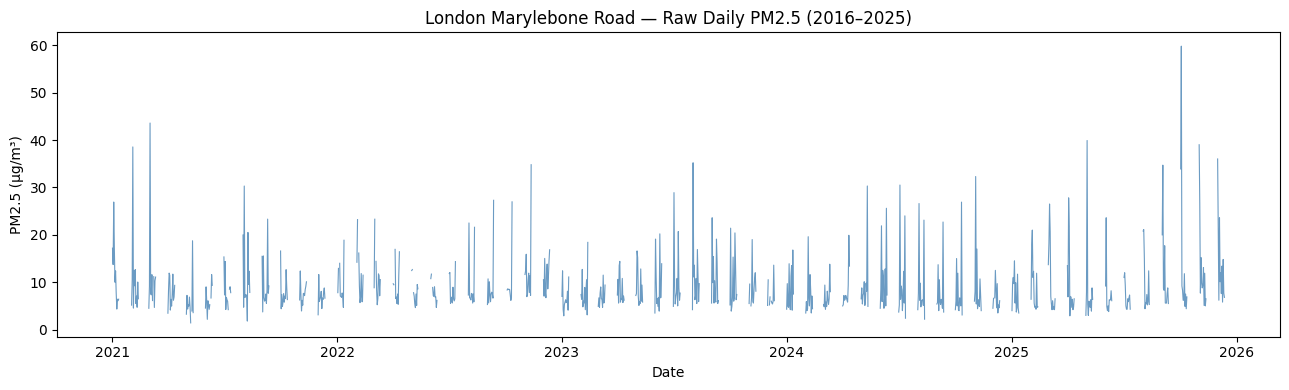

Saved: pm25_raw_series.png


In [5]:
# Drop negative values — physically impossible for PM2.5
negatives = (df['pm25'] < 0).sum()
df = df[~(df['pm25'] < 0)].copy()
print(f'Negative values removed: {negatives}')

# Reindex to a complete daily date range so gaps are visible
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()
df['station'] = 'London Marylebone Road'

missing_after = df['pm25'].isna().sum()
print(f'Missing values after reindex: {missing_after} ({missing_after/len(df)*100:.1f}%)')
print(f'Total days in series: {len(df)}')

# Plot raw time series
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['date'], df['pm25'], linewidth=0.8, color='steelblue', alpha=0.8)
ax.set_title('London Marylebone Road — Raw Daily PM2.5 (2016–2025)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.savefig('pm25_raw_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_raw_series.png')

## 3. Fill Missing Values
Use linear interpolation for short gaps (1-3 days) and forward/backward fill for any remaining gaps.

In [6]:
# Record which values were originally observed vs filled
df['was_observed'] = df['pm25'].notna()

# Linear interpolation — limit to 3 consecutive days
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3, limit_area='inside')

# Forward fill then backward fill for any remaining gaps at edges
df['pm25'] = df['pm25'].ffill().bfill()

df['pm25_imputed'] = ~df['was_observed']

print(f'Values after interpolation: {df["pm25"].notna().sum()}')
print(f'Still missing: {df["pm25"].isna().sum()}')
print(f'Imputed rows: {df["pm25_imputed"].sum()}')
df.head()

Values after interpolation: 1807
Still missing: 0
Imputed rows: 1120


,date,pm25,station,was_observed,pm25_imputed
0,2021-01-01,17.167,London Marylebone Road,True,False
1,2021-01-02,13.724,London Marylebone Road,True,False
2,2021-01-03,26.917,London Marylebone Road,True,False
3,2021-01-04,17.167,London Marylebone Road,True,False
4,2021-01-05,10.000,London Marylebone Road,True,False


## 4. Raw Lag Features
Past PM2.5 values as direct inputs — what the model saw on previous days.

In [7]:
# Lag features — PM2.5 value from N days ago
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'pm25_lag_{lag}d'] = df['pm25'].shift(lag)

lag_features = [f'pm25_lag_{lag}d' for lag in [1, 2, 3, 7, 14, 30]]

print(f'Lag features added: {lag_features}')
print()
print('Sample (first 10 rows):')
print(df[['date', 'pm25'] + lag_features].head(10).to_string(index=False))

Lag features added: ['pm25_lag_1d', 'pm25_lag_2d', 'pm25_lag_3d', 'pm25_lag_7d', 'pm25_lag_14d', 'pm25_lag_30d']

Sample (first 10 rows):
      date   pm25  pm25_lag_1d  pm25_lag_2d  pm25_lag_3d  pm25_lag_7d  pm25_lag_14d  pm25_lag_30d
2021-01-01 17.167          NaN          NaN          NaN          NaN           NaN           NaN
2021-01-02 13.724       17.167          NaN          NaN          NaN           NaN           NaN
2021-01-03 26.917       13.724       17.167          NaN          NaN           NaN           NaN
2021-01-04 17.167       26.917       13.724       17.167          NaN           NaN           NaN
2021-01-05 10.000       17.167       26.917       13.724          NaN           NaN           NaN
2021-01-06 12.385       10.000       17.167       26.917          NaN           NaN           NaN
2021-01-07  7.720       12.385       10.000       17.167          NaN           NaN           NaN
2021-01-08  4.333        7.720       12.385       10.000       17.167         

## 5. Rolling Averages and Statistics
Smoothed representations of past PM2.5 levels — capture short and medium term trends.

Rolling features added: 10
['rolling_mean_3d', 'rolling_mean_7d', 'rolling_mean_14d', 'rolling_mean_30d', 'rolling_std_7d', 'rolling_std_30d', 'rolling_min_7d', 'rolling_min_30d', 'rolling_max_7d', 'rolling_max_30d']


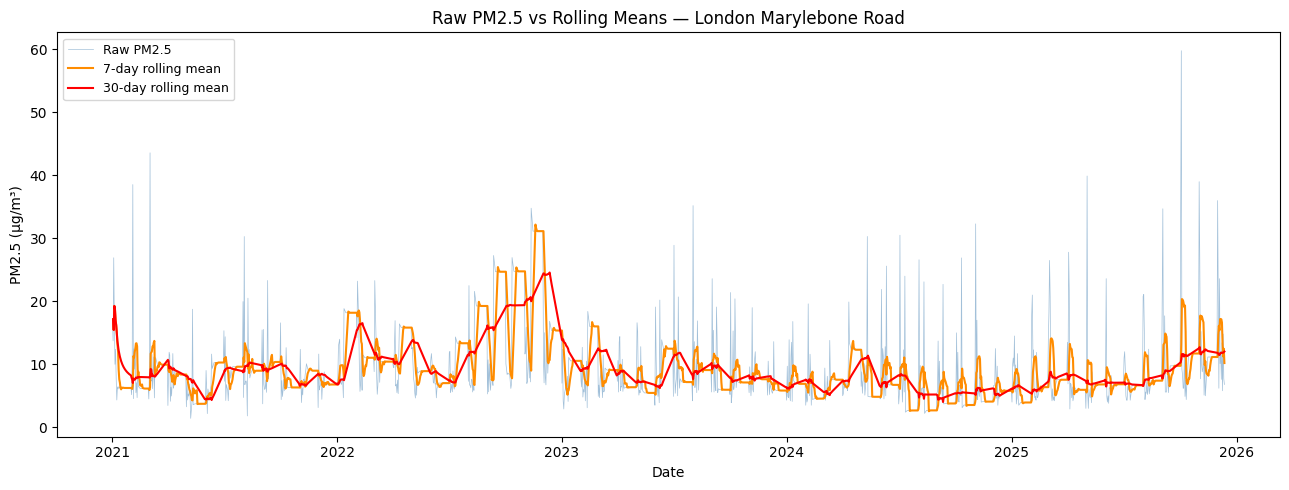

Saved: pm25_rolling_means.png


In [8]:
# Rolling means
for window in [3, 7, 14, 30]:
    df[f'rolling_mean_{window}d'] = df['pm25'].shift(1).rolling(window, min_periods=1).mean()

# Rolling std, min, max
for window in [7, 30]:
    df[f'rolling_std_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=2).std()
    df[f'rolling_min_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).min()
    df[f'rolling_max_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).max()

rolling_features = (
    [f'rolling_mean_{w}d' for w in [3, 7, 14, 30]] +
    [f'rolling_std_{w}d'  for w in [7, 30]] +
    [f'rolling_min_{w}d'  for w in [7, 30]] +
    [f'rolling_max_{w}d'  for w in [7, 30]]
)

print(f'Rolling features added: {len(rolling_features)}')
print(rolling_features)

# Plot rolling means vs raw
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['date'], df['pm25'], linewidth=0.5, color='steelblue', alpha=0.5, label='Raw PM2.5')
ax.plot(df['date'], df['rolling_mean_7d'],  linewidth=1.5, color='darkorange', label='7-day rolling mean')
ax.plot(df['date'], df['rolling_mean_30d'], linewidth=1.5, color='red',        label='30-day rolling mean')
ax.set_title('Raw PM2.5 vs Rolling Means — London Marylebone Road', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pm25_rolling_means.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_rolling_means.png')

In [10]:
all_features_updated = lag_features + rolling_features + roc_features + seasonal_features + trend_attr_features + cyclical_features

# Correlation with pm25 (next day — shifted back)
df['pm25_next_day'] = df['pm25'].shift(-1)  # target: tomorrow's PM2.5

corr_with_target_updated = (
    df[all_features_updated + ['pm25_next_day']]
    .corr()['pm25_next_day']
    .drop('pm25_next_day')
    .sort_values(ascending=False)
)

print('Top 15 features correlated with next-day PM2.5 (updated):')
print(corr_with_target_updated.head(15).round(3).to_string())

# Bar chart
top15_updated = corr_with_target_updated.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in top15_updated.values]
ax.barh(top15_updated.index[::-1], top15_updated.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 15 Feature Correlations with Next-Day PM2.5 (Updated)', fontsize=11)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('pm25_feature_correlations_updated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_feature_correlations_updated.png')


NameError: name 'roc_features' is not defined

In [19]:
# Drop the target shift column before saving
df = df.drop(columns=['pm25_next_day'], errors='ignore')

df.to_csv('pm25_historical_features_updated.csv', index=False)
print('Saved: pm25_historical_features_updated.csv')

print(f"""
=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}

Lag features          : {len(lag_features)}
Rolling features      : {len(rolling_features)}
Rate of change        : {len(roc_features)}
Seasonal components   : {len(seasonal_features)}
Trend attributes      : {len(trend_attr_features)}
Cyclical features     : {len(cyclical_features)}
------------------------------
Total features added  : {len(all_features_updated)}
Final df shape        : {df.shape}
==============================
""")

df.head(10)

Saved: pm25_historical_features_updated.csv

=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-12
Total records  : 1,807

Lag features          : 6
Rolling features      : 10
Rate of change        : 6
Seasonal components   : 3
Trend attributes      : 14
Cyclical features     : 6
------------------------------
Total features added  : 45
Final df shape        : (1807, 50)



,date,pm25,station,was_observed,pm25_imputed,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_7d,pm25_lag_14d,...,trend_volatility_14d,trend_ratio_7d,trend_ratio_30d,trend_cumsum_7d,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos
0,2021-01-01,17.167,London Marylebone Road,True,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.017213,0.999852,-0.433884,-0.900969,0.201299,0.979530
1,2021-01-02,13.724,London Marylebone Road,True,False,17.167,NaN,NaN,NaN,NaN,...,NaN,1.000000,1.000000,17.167,0.034422,0.999407,-0.974928,-0.222521,0.394356,0.918958
2,2021-01-03,26.917,London Marylebone Road,True,False,13.724,17.167,NaN,NaN,NaN,...,2.434569,0.888544,0.888544,30.891,0.051620,0.998667,-0.781831,0.623490,0.571268,0.820763
3,2021-01-04,17.167,London Marylebone Road,True,False,26.917,13.724,17.167,NaN,NaN,...,6.843147,1.396883,1.396883,57.808,0.068802,0.997630,0.000000,1.000000,0.724793,0.688967
4,2021-01-05,10.000,London Marylebone Road,True,False,17.167,26.917,13.724,NaN,NaN,...,5.685425,0.915879,0.915879,74.975,0.085965,0.996298,0.781831,0.623490,0.848644,0.528964
5,2021-01-06,12.385,London Marylebone Road,True,False,10.000,17.167,26.917,NaN,NaN,...,6.287581,0.588408,0.588408,84.975,0.103102,0.994671,0.974928,-0.222521,0.937752,0.347305
6,2021-01-07,7.720,London Marylebone Road,True,False,12.385,10.000,17.167,NaN,NaN,...,5.930342,0.763250,0.763250,97.360,0.120208,0.992749,0.433884,-0.900969,0.988468,0.151428
7,2021-01-08,4.333,London Marylebone Road,True,False,7.720,12.385,10.000,17.167,NaN,...,6.296435,0.514275,0.514275,105.080,0.137279,0.990532,-0.433884,-0.900969,0.998717,-0.050649
8,2021-01-09,6.417,London Marylebone Road,True,False,4.333,7.720,12.385,13.724,NaN,...,6.945150,0.328806,0.316818,92.246,0.154309,0.988023,-0.974928,-0.222521,0.968077,-0.250653
9,2021-01-10,6.083,London Marylebone Road,True,False,6.417,4.333,7.720,26.917,NaN,...,6.932642,0.528838,0.498601,84.939,0.171293,0.985220,-0.781831,0.623490,0.897805,-0.440394


## 6. Rate of Change Features
How fast is PM2.5 changing? Captures pollution episodes building up or clearing.

Rate of change features added: ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

      date      pm25   diff_1d    diff_7d  diff_30d  pct_change_1d  pct_change_7d  diff_of_diff
2021-01-01 17.167000       NaN        NaN       NaN            NaN            NaN           NaN
2021-01-02 13.724000       NaN        NaN       NaN            NaN            NaN           NaN
2021-01-03 26.917000 -3.443000        NaN       NaN     -20.055921            NaN           NaN
2021-01-04 17.167000 13.193000        NaN       NaN      96.130866            NaN  1.663600e+01
2021-01-05 10.000000 -9.750000        NaN       NaN     -36.222462            NaN -2.294300e+01
2021-01-06 12.385000 -7.167000        NaN       NaN     -41.748704            NaN  2.583000e+00
2021-01-07  7.720000  2.385000        NaN       NaN      23.850000            NaN  9.552000e+00
2021-01-08  4.333000 -4.665000        NaN       NaN     -37.666532            NaN -7.050000e+00
2021-01-09  6.41700

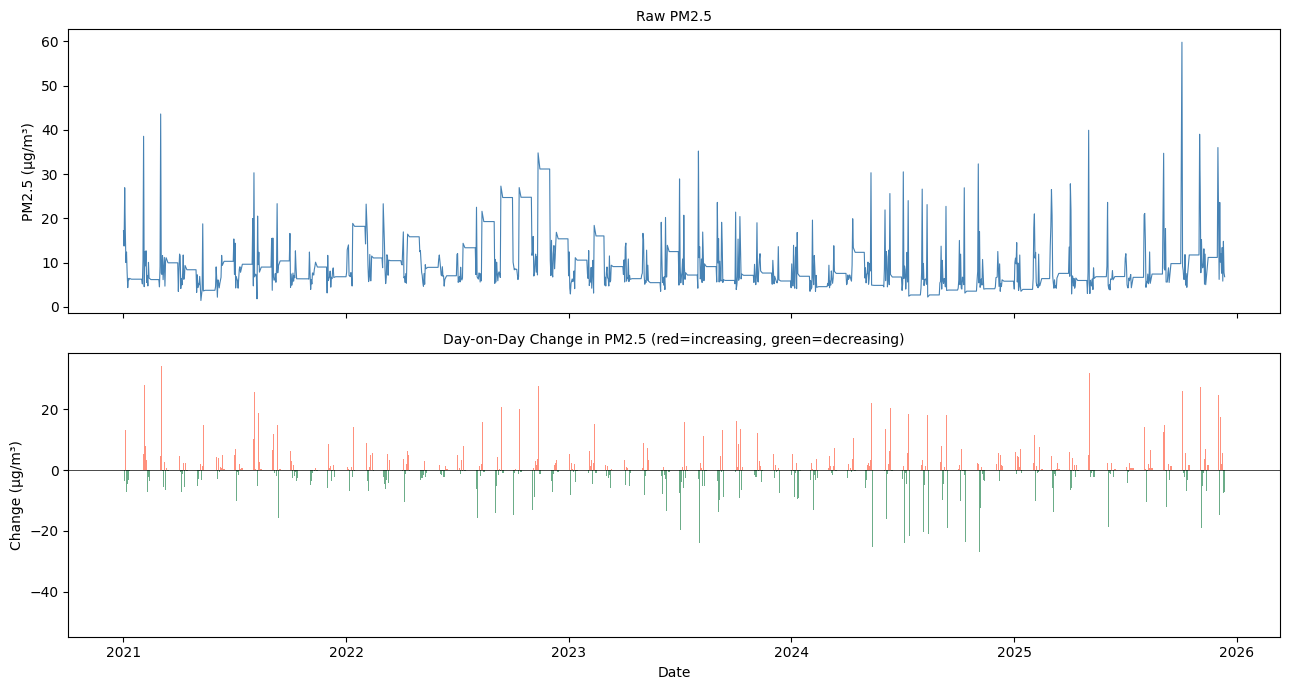

Saved: pm25_rate_of_change.png


In [12]:
# Day-on-day difference (shift so we use yesterday's value, not today's)
df['diff_1d']      = df['pm25'].shift(1).diff(1)    # change from day before
df['diff_7d']      = df['pm25'].shift(1).diff(7)    # change over past 7 days
df['diff_30d']     = df['pm25'].shift(1).diff(30)   # change over past 30 days

# Percentage change from previous day
df['pct_change_1d'] = df['pm25'].shift(1).pct_change(1) * 100
df['pct_change_7d'] = df['pm25'].shift(1).pct_change(7) * 100

# Rate of acceleration (change of change)
df['diff_of_diff'] = df['diff_1d'].diff(1)

roc_features = ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

print(f'Rate of change features added: {roc_features}')
print()
print(df[['date', 'pm25'] + roc_features].head(15).to_string(index=False))

# Plot day-on-day difference
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(df['date'], df['pm25'], linewidth=0.8, color='steelblue')
axes[0].set_title('Raw PM2.5', fontsize=10)
axes[0].set_ylabel('PM2.5 (µg/m³)')

axes[1].bar(df['date'], df['diff_1d'], color=[
    'tomato' if x > 0 else 'seagreen' for x in df['diff_1d'].fillna(0)
], width=1, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Day-on-Day Change in PM2.5 (red=increasing, green=decreasing)', fontsize=10)
axes[1].set_ylabel('Change (µg/m³)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('pm25_rate_of_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_rate_of_change.png')

## 7. Seasonal Decomposition
Extract trend and seasonality components from the PM2.5 signal.

Seasonal features added: ['seasonal_trend', 'seasonal_component', 'seasonal_residual']


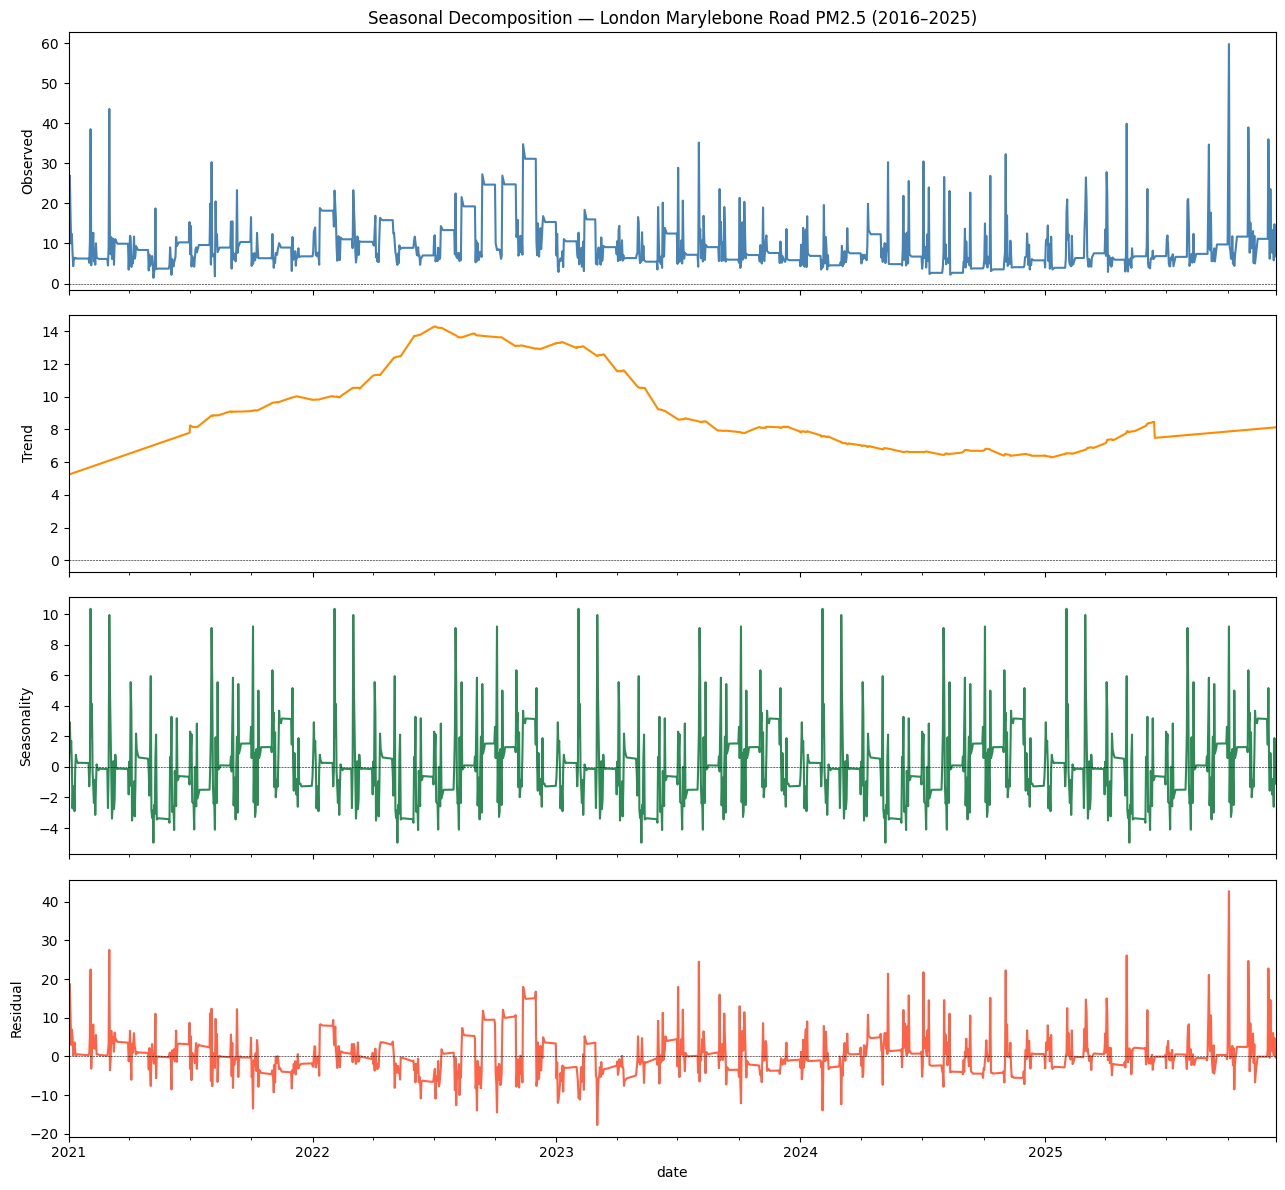

Saved: pm25_seasonal_decomposition.png


In [13]:
# Seasonal decomposition — requires complete series with no NaNs
pm25_series = df.set_index('date')['pm25'].fillna(method='ffill')

# Annual seasonality period = 365 days
decomp = seasonal_decompose(pm25_series, model='additive', period=365, extrapolate_trend='freq')

# Add components back to df as features
df['seasonal_trend']      = decomp.trend.values
df['seasonal_component']  = decomp.seasonal.values
df['seasonal_residual']   = decomp.resid.values

seasonal_features = ['seasonal_trend', 'seasonal_component', 'seasonal_residual']
print(f'Seasonal features added: {seasonal_features}')

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)
decomp.observed.plot(ax=axes[0],  color='steelblue');  axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1],     color='darkorange'); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2],  color='seagreen');   axes[2].set_ylabel('Seasonality')
decomp.resid.plot(ax=axes[3],     color='tomato');     axes[3].set_ylabel('Residual')

for ax in axes:
    ax.axhline(0, color='black', linewidth=0.4, linestyle='--')

axes[0].set_title('Seasonal Decomposition — London Marylebone Road PM2.5 (2016–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('pm25_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_seasonal_decomposition.png')

## 8. Extracted Trend Attributes (from Wood 2024)
Based on the univariate approach in Wood (2024) — extracting 15 trend attributes from prior PM2.5 recordings.

In [14]:
# Rolling averages over different windows (using yesterday's value onwards)
for w in [3, 7, 14]:
    df[f'trend_avg_{w}d'] = df['pm25'].shift(1).rolling(w, min_periods=1).mean()

# Differences between specific past days
df['trend_diff_1_2']  = df['pm25'].shift(1) - df['pm25'].shift(2)   # yesterday vs 2 days ago
df['trend_diff_1_7']  = df['pm25'].shift(1) - df['pm25'].shift(7)   # yesterday vs last week
df['trend_diff_7_14'] = df['pm25'].shift(7) - df['pm25'].shift(14)  # last week vs 2 weeks ago

# Rates of change over different windows
df['trend_rate_3d']  = (df['pm25'].shift(1) - df['pm25'].shift(3))  / 3
df['trend_rate_7d']  = (df['pm25'].shift(1) - df['pm25'].shift(7))  / 7
df['trend_rate_14d'] = (df['pm25'].shift(1) - df['pm25'].shift(14)) / 14

# Volatility — rolling standard deviation
df['trend_volatility_7d']  = df['pm25'].shift(1).rolling(7,  min_periods=2).std()
df['trend_volatility_14d'] = df['pm25'].shift(1).rolling(14, min_periods=2).std()

# Ratio of current to rolling mean (how far from recent average)
df['trend_ratio_7d']  = df['pm25'].shift(1) / df[f'rolling_mean_7d'].replace(0, np.nan)
df['trend_ratio_30d'] = df['pm25'].shift(1) / df[f'rolling_mean_30d'].replace(0, np.nan)

# Cumulative sum over past 7 days (total pollution load)
df['trend_cumsum_7d'] = df['pm25'].shift(1).rolling(7, min_periods=1).sum()

trend_attr_features = [
    'trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d',
    'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14',
    'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d',
    'trend_volatility_7d', 'trend_volatility_14d',
    'trend_ratio_7d', 'trend_ratio_30d',
    'trend_cumsum_7d'
]

print(f'Trend attribute features added: {len(trend_attr_features)}')
print(trend_attr_features)
print()
print(df[['date', 'pm25'] + trend_attr_features].head(10).to_string(index=False))

Trend attribute features added: 14
['trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d', 'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14', 'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d', 'trend_volatility_7d', 'trend_volatility_14d', 'trend_ratio_7d', 'trend_ratio_30d', 'trend_cumsum_7d']

      date   pm25  trend_avg_3d  trend_avg_7d  trend_avg_14d  trend_diff_1_2  trend_diff_1_7  trend_diff_7_14  trend_rate_3d  trend_rate_7d  trend_rate_14d  trend_volatility_7d  trend_volatility_14d  trend_ratio_7d  trend_ratio_30d  trend_cumsum_7d
2021-01-01 17.167           NaN           NaN            NaN             NaN             NaN              NaN            NaN            NaN             NaN                  NaN                   NaN             NaN              NaN              NaN
2021-01-02 13.724     17.167000     17.167000      17.167000             NaN             NaN              NaN            NaN            NaN             NaN                  NaN                   NaN        

### Cyclical Features This section generates cyclical features for 'day of year', 'day of week', and 'day of month'. These features are encoded using sine and cosine transformations to represent their periodic nature, enabling models to capture daily, weekly, and annual fluctuations in PM2.5 levels.

In [15]:
# Day of year
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)

# Day of week (Monday=0, Sunday=6)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)

# Day of month
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)

cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

print(f'Cyclical features added: {cyclical_features}')
print('\nSample (first 10 rows with new features):')
print(df[['date'] + cyclical_features].head(10).to_string(index=False))

Cyclical features added: ['day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos']

Sample (first 10 rows with new features):
      date  day_of_year_sin  day_of_year_cos  day_of_week_sin  day_of_week_cos  day_of_month_sin  day_of_month_cos
2021-01-01         0.017213         0.999852        -0.433884        -0.900969          0.201299          0.979530
2021-01-02         0.034422         0.999407        -0.974928        -0.222521          0.394356          0.918958
2021-01-03         0.051620         0.998667        -0.781831         0.623490          0.571268          0.820763
2021-01-04         0.068802         0.997630         0.000000         1.000000          0.724793          0.688967
2021-01-05         0.085965         0.996298         0.781831         0.623490          0.848644          0.528964
2021-01-06         0.103102         0.994671         0.974928        -0.222521          0.937752          0.347305
2021-01-07

### Feature Correlation with PM2.5 (Updated) This section re-evaluates feature correlation with the next day's PM2.5 level, including newly added cyclical components. The top 15 features strongest correlated with future PM2.5 values are visualized to assess their predictive power.

Top 15 features correlated with next-day PM2.5 (updated):
rolling_mean_3d      0.588
trend_avg_3d         0.588
rolling_mean_7d      0.571
trend_avg_7d         0.571
trend_cumsum_7d      0.566
rolling_min_7d       0.546
pm25_lag_1d          0.543
rolling_mean_30d     0.538
pm25_lag_30d         0.525
trend_avg_14d        0.519
rolling_mean_14d     0.519
pm25_lag_2d          0.504
pm25_lag_3d          0.451
seasonal_residual    0.445
seasonal_trend       0.391


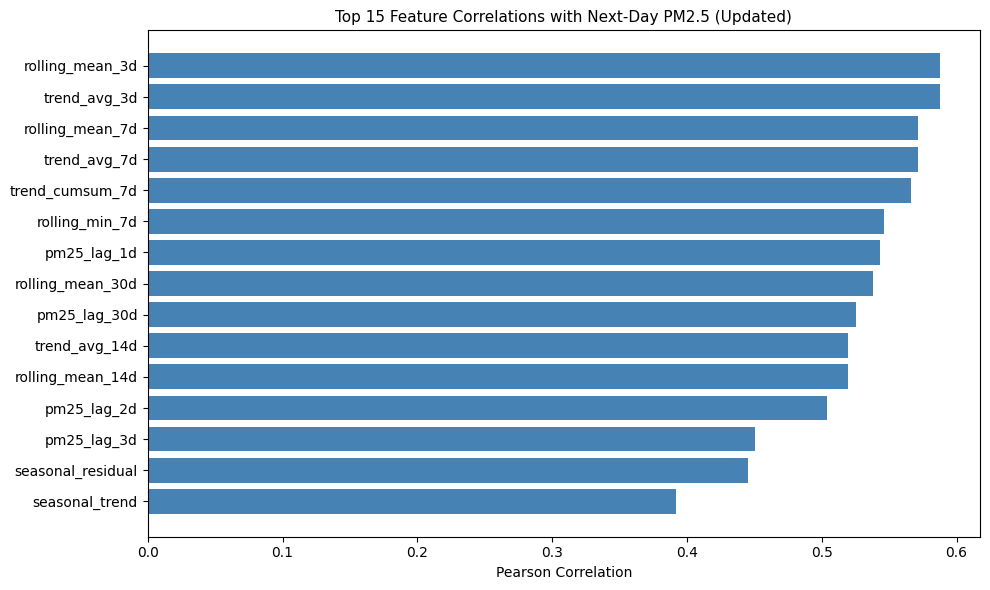

Saved: pm25_feature_correlations_updated.png


In [16]:
all_features_updated = lag_features + rolling_features + roc_features + seasonal_features + trend_attr_features + cyclical_features

# Correlation with pm25 (next day — shifted back)
df['pm25_next_day'] = df['pm25'].shift(-1)  # target: tomorrow's PM2.5

corr_with_target_updated = (
    df[all_features_updated + ['pm25_next_day']]
    .corr()['pm25_next_day']
    .drop('pm25_next_day')
    .sort_values(ascending=False)
)

print('Top 15 features correlated with next-day PM2.5 (updated):')
print(corr_with_target_updated.head(15).round(3).to_string())

# Bar chart
top15_updated = corr_with_target_updated.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in top15_updated.values]
ax.barh(top15_updated.index[::-1], top15_updated.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title('Top 15 Feature Correlations with Next-Day PM2.5 (Updated)', fontsize=11)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('pm25_feature_correlations_updated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_feature_correlations_updated.png')


### Save Output (Updated) This step saves the DataFrame, containing all engineered historical PM2.5 trend attributes and cyclical features, to `pm25_historical_features_updated.csv`. A summary of the feature engineering process and the final DataFrame shape is also displayed.

In [17]:
# Drop the target shift column before saving
df = df.drop(columns=['pm25_next_day'], errors='ignore')

df.to_csv('pm25_historical_features_updated.csv', index=False)
print('Saved: pm25_historical_features_updated.csv')

print(f"""
=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : {df['date'].min().date()} to {df['date'].max().date()}
Total records  : {len(df):,}

Lag features          : {len(lag_features)}
Rolling features      : {len(rolling_features)}
Rate of change        : {len(roc_features)}
Seasonal components   : {len(seasonal_features)}
Trend attributes      : {len(trend_attr_features)}
Cyclical features     : {len(cyclical_features)}
------------------------------
Total features added  : {len(all_features_updated)}
Final df shape        : {df.shape}
==============================
""")

df.head(10)

Saved: pm25_historical_features_updated.csv

=== TASK 1 FEATURE SUMMARY (UPDATED) ===
Station        : London Marylebone Road
Date range     : 2021-01-01 to 2025-12-12
Total records  : 1,807

Lag features          : 6
Rolling features      : 10
Rate of change        : 6
Seasonal components   : 3
Trend attributes      : 14
Cyclical features     : 6
------------------------------
Total features added  : 45
Final df shape        : (1807, 50)



,date,pm25,station,was_observed,pm25_imputed,pm25_lag_1d,pm25_lag_2d,pm25_lag_3d,pm25_lag_7d,pm25_lag_14d,...,trend_volatility_14d,trend_ratio_7d,trend_ratio_30d,trend_cumsum_7d,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos
0,2021-01-01,17.167,London Marylebone Road,True,False,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.017213,0.999852,-0.433884,-0.900969,0.201299,0.979530
1,2021-01-02,13.724,London Marylebone Road,True,False,17.167,NaN,NaN,NaN,NaN,...,NaN,1.000000,1.000000,17.167,0.034422,0.999407,-0.974928,-0.222521,0.394356,0.918958
2,2021-01-03,26.917,London Marylebone Road,True,False,13.724,17.167,NaN,NaN,NaN,...,2.434569,0.888544,0.888544,30.891,0.051620,0.998667,-0.781831,0.623490,0.571268,0.820763
3,2021-01-04,17.167,London Marylebone Road,True,False,26.917,13.724,17.167,NaN,NaN,...,6.843147,1.396883,1.396883,57.808,0.068802,0.997630,0.000000,1.000000,0.724793,0.688967
4,2021-01-05,10.000,London Marylebone Road,True,False,17.167,26.917,13.724,NaN,NaN,...,5.685425,0.915879,0.915879,74.975,0.085965,0.996298,0.781831,0.623490,0.848644,0.528964
5,2021-01-06,12.385,London Marylebone Road,True,False,10.000,17.167,26.917,NaN,NaN,...,6.287581,0.588408,0.588408,84.975,0.103102,0.994671,0.974928,-0.222521,0.937752,0.347305
6,2021-01-07,7.720,London Marylebone Road,True,False,12.385,10.000,17.167,NaN,NaN,...,5.930342,0.763250,0.763250,97.360,0.120208,0.992749,0.433884,-0.900969,0.988468,0.151428
7,2021-01-08,4.333,London Marylebone Road,True,False,7.720,12.385,10.000,17.167,NaN,...,6.296435,0.514275,0.514275,105.080,0.137279,0.990532,-0.433884,-0.900969,0.998717,-0.050649
8,2021-01-09,6.417,London Marylebone Road,True,False,4.333,7.720,12.385,13.724,NaN,...,6.945150,0.328806,0.316818,92.246,0.154309,0.988023,-0.974928,-0.222521,0.968077,-0.250653
9,2021-01-10,6.083,London Marylebone Road,True,False,6.417,4.333,7.720,26.917,NaN,...,6.932642,0.528838,0.498601,84.939,0.171293,0.985220,-0.781831,0.623490,0.897805,-0.440394


## Rebuilding DataFrame with All Features (to fix `KeyError`)

To ensure all features (lag, rolling, ROC, seasonal, trend attributes, and cyclical) are present for correlation calculation, we'll re-run all feature engineering steps on a fresh DataFrame.

In [18]:
# Re-load raw data
def load_defra_single_station(filepath):
    raw = pd.read_csv(filepath, skiprows=11, header=None, usecols=[0, 1], names=['date', 'pm25'])
    raw = raw[raw['date'].astype(str).str.match(r'\d{4}|\d{2}/\d{2}/\d{4}', na=False)]
    raw['date'] = pd.to_datetime(raw['date'], dayfirst=True, errors='coerce').dt.normalize()
    raw['pm25'] = pd.to_numeric(raw['pm25'], errors='coerce')
    raw = raw.dropna(subset=['date'])
    return raw

df = load_defra_single_station('/content/PM2.5_AirQualityDataDaily_2021-2025.csv')
df = df.sort_values('date').drop_duplicates('date').reset_index(drop=True)
df['station'] = 'London Marylebone Road'

# Basic Cleaning
df = df[~(df['pm25'] < 0)].copy()
full_idx = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
df = df.set_index('date').reindex(full_idx).rename_axis('date').reset_index()
df['station'] = 'London Marylebone Road'

# Fill Missing Values
df['was_observed'] = df['pm25'].notna()
df['pm25'] = df['pm25'].interpolate(method='linear', limit=3, limit_area='inside')
df['pm25'] = df['pm25'].ffill().bfill()
df['pm25_imputed'] = ~df['was_observed']

# Raw Lag Features
for lag in [1, 2, 3, 7, 14, 30]:
    df[f'pm25_lag_{lag}d'] = df['pm25'].shift(lag)
lag_features = [f'pm25_lag_{lag}d' for lag in [1, 2, 3, 7, 14, 30]]

# Rolling Averages and Statistics
for window in [3, 7, 14, 30]:
    df[f'rolling_mean_{window}d'] = df['pm25'].shift(1).rolling(window, min_periods=1).mean()
for window in [7, 30]:
    df[f'rolling_std_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=2).std()
    df[f'rolling_min_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).min()
    df[f'rolling_max_{window}d']  = df['pm25'].shift(1).rolling(window, min_periods=1).max()
rolling_features = (
    [f'rolling_mean_{w}d' for w in [3, 7, 14, 30]] +
    [f'rolling_std_{w}d'  for w in [7, 30]] +
    [f'rolling_min_{w}d'  for w in [7, 30]] +
    [f'rolling_max_{w}d'  for w in [7, 30]]
)

# Rate of Change Features
df['diff_1d']      = df['pm25'].shift(1).diff(1)
df['diff_7d']      = df['pm25'].shift(1).diff(7)
df['diff_30d']     = df['pm25'].shift(1).diff(30)
df['pct_change_1d'] = df['pm25'].shift(1).pct_change(1) * 100
df['pct_change_7d'] = df['pm25'].shift(1).pct_change(7) * 100
df['diff_of_diff'] = df['diff_1d'].diff(1)
roc_features = ['diff_1d', 'diff_7d', 'diff_30d', 'pct_change_1d', 'pct_change_7d', 'diff_of_diff']

# Seasonal Decomposition
pm25_series = df.set_index('date')['pm25'].fillna(method='ffill')
decomp = seasonal_decompose(pm25_series, model='additive', period=365, extrapolate_trend='freq')
df['seasonal_trend']      = decomp.trend.values
df['seasonal_component']  = decomp.seasonal.values
df['seasonal_residual']   = decomp.resid.values
seasonal_features = ['seasonal_trend', 'seasonal_component', 'seasonal_residual']

# Extracted Trend Attributes (from Wood 2024)
for w in [3, 7, 14]:
    df[f'trend_avg_{w}d'] = df['pm25'].shift(1).rolling(w, min_periods=1).mean()
df['trend_diff_1_2']  = df['pm25'].shift(1) - df['pm25'].shift(2)
df['trend_diff_1_7']  = df['pm25'].shift(1) - df['pm25'].shift(7)
df['trend_diff_7_14'] = df['pm25'].shift(7) - df['pm25'].shift(14)
df['trend_rate_3d']  = (df['pm25'].shift(1) - df['pm25'].shift(3))  / 3
df['trend_rate_7d']  = (df['pm25'].shift(1) - df['pm25'].shift(7))  / 7
df['trend_rate_14d'] = (df['pm25'].shift(1) - df['pm25'].shift(14)) / 14
df['trend_volatility_7d']  = df['pm25'].shift(1).rolling(7,  min_periods=2).std()
df['trend_volatility_14d'] = df['pm25'].shift(1).rolling(14, min_periods=2).std()
df['trend_ratio_7d']  = df['pm25'].shift(1) / df[f'rolling_mean_7d'].replace(0, np.nan)
df['trend_ratio_30d'] = df['pm25'].shift(1) / df[f'rolling_mean_30d'].replace(0, np.nan)
df['trend_cumsum_7d'] = df['pm25'].shift(1).rolling(7, min_periods=1).sum()
trend_attr_features = [
    'trend_avg_3d', 'trend_avg_7d', 'trend_avg_14d',
    'trend_diff_1_2', 'trend_diff_1_7', 'trend_diff_7_14',
    'trend_rate_3d', 'trend_rate_7d', 'trend_rate_14d',
    'trend_volatility_7d', 'trend_volatility_14d',
    'trend_ratio_7d', 'trend_ratio_30d',
    'trend_cumsum_7d'
]

# Cyclical Features (from previous step)
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

# Define the full list of features after all steps
all_features_updated = lag_features + rolling_features + roc_features + seasonal_features + trend_attr_features + cyclical_features

print(f'DataFrame rebuilt with all features. New shape: {df.shape}')
print(f'Total features in all_features_updated: {len(all_features_updated)}')
print(df.head())

DataFrame rebuilt with all features. New shape: (1807, 50)
Total features in all_features_updated: 45
        date    pm25                 station  was_observed  pm25_imputed  \
0 2021-01-01  17.167  London Marylebone Road          True         False   
1 2021-01-02  13.724  London Marylebone Road          True         False   
2 2021-01-03  26.917  London Marylebone Road          True         False   
3 2021-01-04  17.167  London Marylebone Road          True         False   
4 2021-01-05  10.000  London Marylebone Road          True         False   

   pm25_lag_1d  pm25_lag_2d  pm25_lag_3d  pm25_lag_7d  pm25_lag_14d  ...  \
0          NaN          NaN          NaN          NaN           NaN  ...   
1       17.167          NaN          NaN          NaN           NaN  ...   
2       13.724       17.167          NaN          NaN           NaN  ...   
3       26.917       13.724       17.167          NaN           NaN  ...   
4       17.167       26.917       13.724          NaN        

In [25]:
# Day of year
df['day_of_year_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofyear / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofyear / 365)

# Day of week (Monday=0, Sunday=6)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['date'].dt.dayofweek / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['date'].dt.dayofweek / 7)

# Day of month
df['day_of_month_sin'] = np.sin(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)
df['day_of_month_cos'] = np.cos(2 * np.pi * df['date'].dt.day / df['date'].dt.days_in_month)

cyclical_features = [
    'day_of_year_sin', 'day_of_year_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos'
]

print(f'Cyclical features added: {cyclical_features}')
print('\nSample (first 10 rows with new features):')
print(df[['date'] + cyclical_features].head(10).to_string(index=False))

Cyclical features added: ['day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos']

Sample (first 10 rows with new features):
      date  day_of_year_sin  day_of_year_cos  day_of_week_sin  day_of_week_cos  day_of_month_sin  day_of_month_cos
2016-01-01         0.017213         0.999852        -0.433884        -0.900969          0.201299          0.979530
2016-01-02         0.034422         0.999407        -0.974928        -0.222521          0.394356          0.918958
2016-01-03         0.051620         0.998667        -0.781831         0.623490          0.571268          0.820763
2016-01-04         0.068802         0.997630         0.000000         1.000000          0.724793          0.688967
2016-01-05         0.085965         0.996298         0.781831         0.623490          0.848644          0.528964
2016-01-06         0.103102         0.994671         0.974928        -0.222521          0.937752          0.347305
2016-01-07